<a href="https://colab.research.google.com/github/mchlgho22/project1/blob/main/Project_GoogleNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [55]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
# from torchvision.models import resnet50
from torchvision.models import googlenet, GoogLeNet_Weights
import time
from torch.autograd import Variable
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation

In [ ]:
# !rm -rf /content/drive

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
data_path = '/content/drive/MyDrive/FaceRecognition/Dataset'

images_path = os.path.join(data_path, 'Images')
attr_path = os.path.join(data_path, 'list_attribute.txt')
model_dir = os.path.join(data_path, "model_saved")
os.makedirs(model_dir, exist_ok=True)

In [58]:
os.listdir(data_path)

['list_attribute.txt', 'train', 'model_saved', 'Images']

In [59]:
with open(attr_path, 'r') as f:
    lines = f.readlines()

# baris ke-2 adalah nama atribut
columns = lines[1].split()

# data mulai baris ke-3
records = []
for line in lines[2:]:
    parts = line.split()
    img = parts[0]
    attrs = list(map(int, parts[1:]))

    male = attrs[20]   # index Male

    gender = 1 if male == 1 else 0
    records.append([img, gender])

data = pd.DataFrame(records, columns=['image', 'gender'])

# filter hanya image yang ada
images_list = os.listdir(images_path)
data = data[data['image'].isin(images_list)]

# gunakan hanya 5000 data
data = data.sample(5000, random_state=42)

print(data.head())
print(data['gender'].value_counts())

             image  gender
60964   060965.jpg       1
103729  103730.jpg       1
107305  107306.jpg       1
42409   042410.jpg       1
28519   028520.jpg       1
gender
0    2953
1    2047
Name: count, dtype: int64


In [60]:
# split the data into train and test sets with a 80:20 ratio
# train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

train_data, test_data = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data['gender']
)

## Preprocessing

In [81]:
class GenderDataset(Dataset):

    def __init__(self, data, image_folder_path, transform=None):
        self.data = data.reset_index(drop=True)
        self.image_folder_path = image_folder_path
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img_name = self.data.iloc[idx,0]
        label = self.data.iloc[idx,1]

        img_path = os.path.join(self.image_folder_path, img_name)
        # please define image convertion technique to RGB here
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


In [82]:
# transform = transforms.Compose([
#     # please define data transformation techniques here
# ])
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [83]:
train_set = GenderDataset(train_data, images_path, train_transform)
test_set = GenderDataset(test_data, images_path, test_transform)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, num_workers=2)

## Architecture

In [84]:
print(torch.cuda.is_available())   # True kalau GPU bisa dipakai
print(torch.cuda.get_device_name(0))  # Nama GPU

True
Tesla T4


In [85]:
# use_gpu = torch.cuda.is_available()

# if use_gpu:
#   model = model.to("cuda")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [86]:
# # please define the model optimizer and criterion (loss function)
# model = None
# optimizer = None
# criterion = None

weights = GoogLeNet_Weights.IMAGENET1K_V1
model = googlenet(weights=weights)  # jangan set aux_logits

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

In [87]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

## Modeling

In [88]:
# # def train_model(model, dataloaders, dataset_sizes, criterion, optimizer, use_gpu=torch.cuda.is_available(), num_epochs=10):
# #     # please define the training model (VGG/GoogleNet/ResNet) here
# #     pass

def train_model(model, dataloaders, dataset_sizes, criterion, optimizer, num_epochs=10):
    best_acc = 0.0
    since = time.time()

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-"*30)

        for phase in ['train','test']:
            model.train() if phase=='train' else model.eval()
            running_loss, running_corrects = 0,0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=='train'):
                    outputs = model(inputs)
                    if hasattr(outputs, "logits"):
                        outputs = outputs.logits  # penting agar compatible
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs,1)
                    if phase=='train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item()*inputs.size(0)
                running_corrects += torch.sum(preds==labels.data)

            epoch_loss = running_loss/dataset_sizes[phase]
            epoch_acc = running_corrects.double()/dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase=='test' and epoch_acc > best_acc:
                best_acc = epoch_acc
                #Save Model
                torch.save(model.state_dict(), os.path.join(model_dir,"best_model.pth"))

    print(f"\nTraining complete in {(time.time()-since)/60:.2f} minutes")
    print(f"Best test accuracy: {best_acc:.4f}")
    return model

In [89]:
# Train Model
dataloaders = {"train": train_loader, "test": test_loader}
dataset_sizes = {"train": len(train_set), "test": len(test_set)}

In [90]:
# model = train_model(model, dataloaders, dataset_sizes, criterion, optimizer, use_gpu, 10)
model = train_model(model, dataloaders, dataset_sizes, criterion, optimizer, num_epochs=10)


Epoch 1/10
------------------------------
train Loss: 0.2317 Acc: 0.9050
test Loss: 0.1319 Acc: 0.9480

Epoch 2/10
------------------------------
train Loss: 0.0959 Acc: 0.9613
test Loss: 0.1119 Acc: 0.9580

Epoch 3/10
------------------------------
train Loss: 0.0612 Acc: 0.9778
test Loss: 0.1140 Acc: 0.9600

Epoch 4/10
------------------------------
train Loss: 0.0420 Acc: 0.9855
test Loss: 0.1612 Acc: 0.9560

Epoch 5/10
------------------------------
train Loss: 0.0364 Acc: 0.9870
test Loss: 0.0847 Acc: 0.9690

Epoch 6/10
------------------------------
train Loss: 0.0263 Acc: 0.9915
test Loss: 0.0994 Acc: 0.9680

Epoch 7/10
------------------------------
train Loss: 0.0221 Acc: 0.9920
test Loss: 0.0989 Acc: 0.9660

Epoch 8/10
------------------------------
train Loss: 0.0166 Acc: 0.9940
test Loss: 0.1113 Acc: 0.9600

Epoch 9/10
------------------------------
train Loss: 0.0142 Acc: 0.9955
test Loss: 0.1305 Acc: 0.9660

Epoch 10/10
------------------------------
train Loss: 0.0209 A

In [91]:
# Load Model
model.load_state_dict(torch.load(os.path.join(model_dir,"best_model.pth")))
model.eval()

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

## Evaluation

In [92]:
# def evaluate_model(model, test_loader, target_labels):
#     # please define the evaluation function here
#     pass
def evaluate_model(model, test_loader, target_labels):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            if torch.cuda.is_available():
                images = images.cuda()

            outputs = model(images)

            _, preds = torch.max(outputs,1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("Classification Report")
    print(classification_report(all_labels, all_preds, target_names=target_labels))

    cm = confusion_matrix(all_labels, all_preds)

    print("Confusion Matrix")
    print(cm)

     # Plot Confusion Matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=target_labels,
                yticklabels=target_labels)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

Classification Report
              precision    recall  f1-score   support

      female       0.97      0.97      0.97       591
        male       0.96      0.96      0.96       409

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000

Confusion Matrix
[[575  16]
 [ 15 394]]


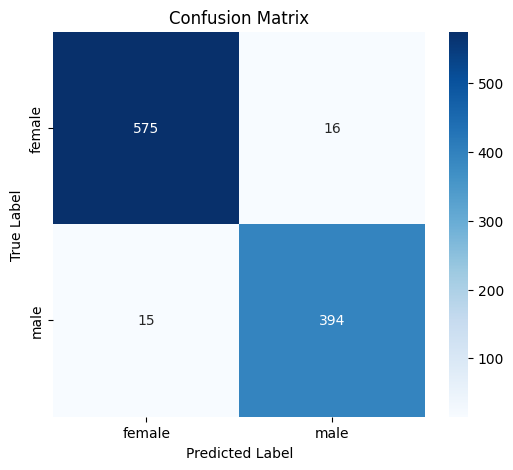

In [93]:
evaluate_model(model, dataloaders['test'], ["female", "male"])

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import torch

class_names = ["female", "male"]

def visualize_predictions(model, dataloader, num_images=8):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    images_shown = 0
    correct = 0
    total = 0

    fig = plt.figure(figsize=(12,6))

    with torch.no_grad():
        for inputs, labels in dataloader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            # Menabahkan accuracy setiap gambar
            probs = torch.softmax(outputs, dim=1)
            confidences, preds = torch.max(probs, 1)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            _, preds = torch.max(outputs, 1)

            # hitung accuracy
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            for j in range(inputs.size(0)):

                if images_shown == num_images:
                    plt.tight_layout()
                    plt.show()

                    accuracy = 100 * correct / total
                    print(f"Accuracy: {accuracy:.2f}% ({correct}/{total})")

                    return

                ax = plt.subplot(2, num_images//2, images_shown + 1)
                ax.axis('off')

                img = inputs[j].cpu().numpy().transpose((1,2,0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                ax.imshow(img)

                true_label = class_names[labels[j]]
                pred_label = class_names[preds[j]]

                color = "green" if preds[j] == labels[j] else "red"
                # ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)

                confidence = confidences[j].item() * 100

                ax.set_title(
                    f"Pred: {pred_label} ({confidence:.1f}%)\nTrue: {true_label}",
                    color=color
                )

                images_shown += 1

    accuracy = 100 * correct / total
    print(f"Accuracy: {accuracy:.2f}% ({correct}/{total})")

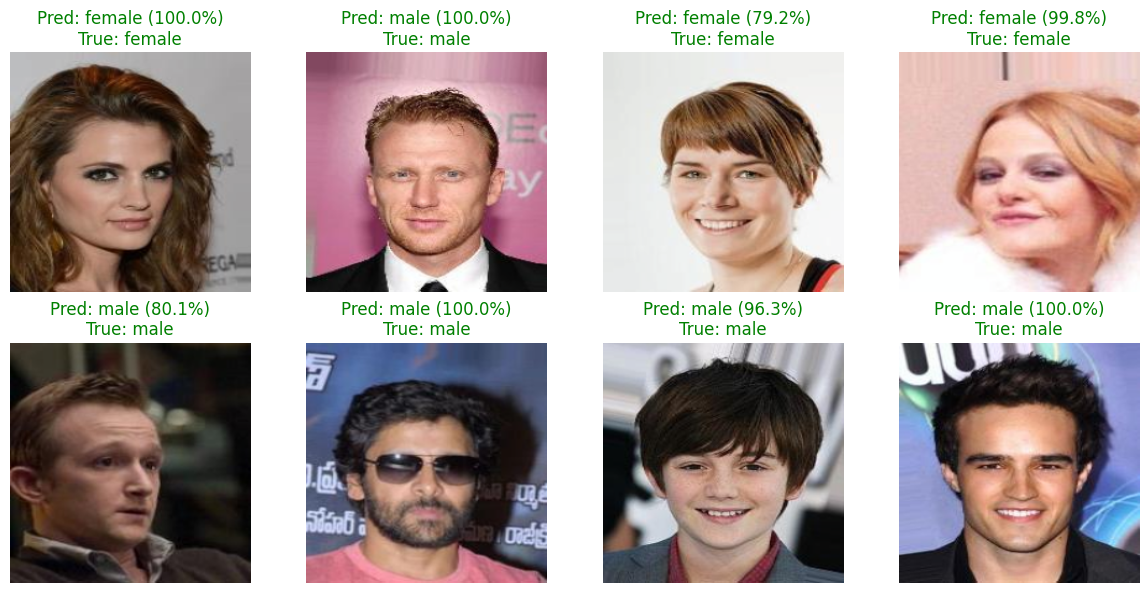

Accuracy: 93.75% (30/32)


In [95]:
visualize_predictions(model, dataloaders['test'], num_images=8)

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Subset
import random

class_names = ["female", "male"]

def visualize_incorrect_predictions(model, dataset, num_images=16):
    """
    Visualisasi gambar dari dataset, menampilkan prediksi yang salah dengan merah.
    """

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    # Pilih index acak dari dataset
    indices = random.sample(range(len(dataset)), min(num_images*4, len(dataset)))  # ambil lebih banyak supaya ada beberapa salah
    subset = Subset(dataset, indices)
    loader = torch.utils.data.DataLoader(subset, batch_size=32, shuffle=False)

    images_shown = 0
    fig = plt.figure(figsize=(16, 16))

    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                inputs, labels, img_names = batch
            else:
                inputs, labels = batch
                img_names = [""] * inputs.size(0)

            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if hasattr(outputs, "logits"):
                outputs = outputs.logits
            probs = torch.softmax(outputs, dim=1)
            confidences, preds = torch.max(probs, 1)

            for j in range(inputs.size(0)):
                if images_shown == num_images:
                    plt.tight_layout()
                    plt.show()
                    return

                # tampilkan hanya jika prediksi salah
                if preds[j] != labels[j]:
                    ax = plt.subplot(4, 4, images_shown + 1)
                    ax.axis('off')

                    img = inputs[j].cpu().numpy().transpose((1,2,0))
                    mean = np.array([0.485,0.456,0.406])
                    std = np.array([0.229,0.224,0.225])
                    img = std*img + mean
                    img = np.clip(img,0,1)

                    ax.imshow(img)

                    true_label = class_names[labels[j]]
                    pred_label = class_names[preds[j]]
                    confidence = confidences[j].item() * 100

                    # merah karena salah prediksi
                    color = "red"

                    ax.set_title(
                        f"{img_names[j]}\nPred: {pred_label} ({confidence:.1f}%)\nTrue: {true_label}",
                        color=color,
                        fontsize=9
                    )

                    images_shown += 1

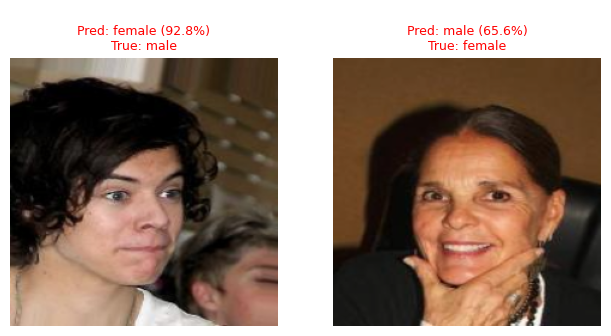

In [96]:
visualize_incorrect_predictions(model, test_set, num_images=16)